# Embedding filters 5 — Memory bank & learned propagation

Two answers to "one filtered vector per track is not enough memory":

1. **Gallery (feature bank)** — store the last `K` embeddings per
   track and match a detection against the *best* of them
   (DeepSORT / MeMOT). One good past view re-associates an object
   whose current appearance has drifted.
2. **Learned propagation (MOTR-style)** — let a trained module
   propagate the track embedding frame to frame, instead of a
   hand-written filter. unitrack exposes this as `LearnedProcess` /
   `LearnedObservation` hooks around any `nn.Module`.


In [1]:
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe

torch.manual_seed(0)

D = 16          # embedding dimensionality (256+ in practice; 16 plots fast)
T = 44          # frames

def make_clip(noise=0.15, seed=0, switch=None):
    """
    A unit embedding that rotates slowly in the (e0, e1) plane plus
    per-frame noise in all D dims. Rotating in a known plane means
    projecting onto dims (0, 1) shows the true path as a circle arc.
    `switch` optionally rotates the plane mid-clip (an appearance change).
    """
    g = torch.Generator().manual_seed(seed)
    t = torch.arange(T).float()
    theta = 0.10 * t
    truth = torch.zeros(T, D)
    truth[:, 0] = torch.cos(theta)
    truth[:, 1] = torch.sin(theta)
    if switch is not None:
        # after `switch`, swap appearance into the (e2, e3) plane.
        truth[switch:, :] = 0.0
        truth[switch:, 2] = torch.cos(theta[switch:])
        truth[switch:, 3] = torch.sin(theta[switch:])
    obs = truth + noise * torch.randn(T, D, generator=g)
    obs = torch.nn.functional.normalize(obs, dim=-1)
    dets = [Detections(index=torch.tensor([0]), emb=obs[k:k + 1].clone(),
                       batch_size=[1]) for k in range(T)]
    return t, truth, obs, dets

def run(tracker, dets, fields=("emb",)):
    """Run a single-object clip through a real Tracker; collect snapshot fields."""
    ms = unitrack.MultiStream(tracker)
    rec = {f: [] for f in fields}
    for k, d in enumerate(dets):
        ctx = FrameContext.make(frame_idx=k, delta=1.0, fps=1.0, stream_key=0)
        res = ms.step(stream_key=0, detections=d, ctx=ctx)
        for f in fields:
            rec[f].append(getattr(res.snapshot, f)[0].clone())
    return {f: torch.stack(v) for f, v in rec.items()}

def cos_to_truth(est, truth):
    e = torch.nn.functional.normalize(est, dim=-1)
    u = torch.nn.functional.normalize(truth, dim=-1)
    return (e * u).sum(-1)

t, truth, obs, dets = make_clip()
print(f"clip: {T} frames, D={D}; raw-detection mean cosine-to-truth "
      f"= {cos_to_truth(obs, truth).mean():.3f}")


clip: 44 frames, D=16; raw-detection mean cosine-to-truth = 0.855


## Gallery beats a single embedding across an appearance switch

We build a two-object clip where object A's appearance **switches**
partway (a viewpoint change), then later a detection resembling its
*old* appearance returns. A single-embedding matcher (`Cosine` on the
latest vector) has forgotten the old look; a `GalleryCost` that keeps
`K` past views still recognises it.


In [2]:
from unitrack.costs import GalleryCost
from unitrack.states import gallery_state_entries

# Tracklet A: appearance in plane (e0,e1). A returning query that looks
# like A's *early* appearance should still match A's gallery.
torch.manual_seed(1)
early = torch.zeros(1, D); early[0, 0] = 1.0
late = torch.zeros(1, D); late[0, 2] = 1.0          # A after a switch
views = [early, 0.5 * (early + late), late]          # A's history, oldest first

gstates = gallery_state_entries("emb", dim=D, capacity=6)
from unitrack.states import FromDetectionField, NoopProcess, State, Replace
single = {"emb": State(schema=TensorSpec(shape=(D,), dtype=torch.float32),
                       process=NoopProcess(), observation=Replace("emb"),
                       init=FromDetectionField("emb"))}

def feed(states, cost):
    tr = unitrack.Tracker(root=Pipe(cost=cost, assoc=Associate(Jonker(threshold=0.6))),
                          states=states, lifecycle=NoLifecycle(), visibility=IncludeAll())
    ms = unitrack.MultiStream(tr)
    snap = None
    for k, v in enumerate(views):
        res = ms.step(stream_key=0, detections=Detections(index=torch.tensor([0]),
                      emb=torch.nn.functional.normalize(v, dim=-1), batch_size=[1]),
                      ctx=FrameContext.make(k, stream_key=0))
        snap = res.snapshot
    return snap

# After observing A's history, a query resembling the EARLY view returns.
query = torch.nn.functional.normalize(early + 0.05 * torch.randn(1, D), dim=-1)
snap_g = feed(dict(gstates), GalleryCost("emb_gallery", "emb_count", "emb", reduce="max"))
snap_s = feed(dict(single), Cosine("emb"))
ds_q = Detections(index=torch.tensor([0]), emb=query, batch_size=[1])
ctx = FrameContext.make(99)
cost_gallery = GalleryCost("emb_gallery", "emb_count", "emb", reduce="max")(
    snap_g, ds_q, ctx).matrix.item()
cost_single = Cosine("emb")(snap_s, ds_q, ctx).matrix.item()
n_views = int(snap_g.emb_count[0].item())
print("returning early-appearance query:")
print(f"  single-embedding cost (latest view only): {cost_single:.3f}  (high -> missed)")
print(f"  gallery cost (best of {n_views} stored views):  "
      f"{cost_gallery:.3f}  (low -> re-associated)")


returning early-appearance query:
  single-embedding cost (latest view only): 1.035  (high -> missed)
  gallery cost (best of 3 stored views):  0.017  (low -> re-associated)


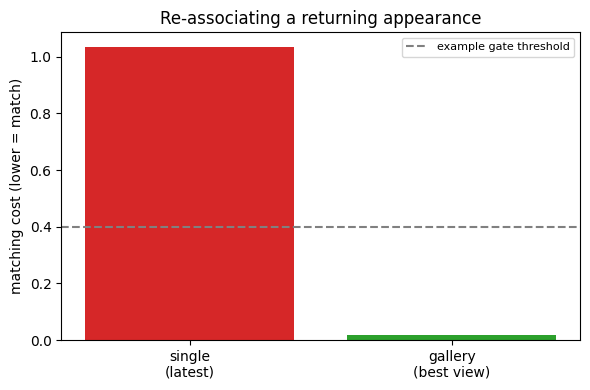

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["single\n(latest)", "gallery\n(best view)"],
       [cost_single, cost_gallery],
       color=["tab:red", "tab:green"])
ax.axhline(0.4, color="0.5", ls="--", label="example gate threshold")
ax.set_ylabel("matching cost (lower = match)")
ax.set_title("Re-associating a returning appearance")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Learned propagation, trained MOTR-style (through the association)

MOTR/MeMOTR do not regress the track query toward a target embedding;
they train it **through the data association** — the query is
propagated, matched against the next frame's detections, and the loss
rewards keeping each identity bound to its detection. The gradient
flows back through the (differentiable) matcher into the propagation
module. We do exactly that here, using unitrack's differentiable
`sinkhorn_log_plan` as the soft matcher.

The scenario is built so propagation is *necessary*: four identities
sit on a circle in feature space and all rotate fast (~54° / frame).
A track that does not anticipate the rotation lags past the midpoint
to its neighbour, so a "match-the-last-embedding" tracker
systematically assigns the wrong identity. Only a module that learns
to rotate the query forward keeps the association correct — and the
only supervision is the association itself.


In [4]:
import torch.nn as nn
from unitrack.assignment import sinkhorn_log_plan
from unitrack.states import (
    FromDetectionField, Identity, LearnedObservation, LearnedProcess,
    Replace, State,
)

N, ROT_T, OMEGA, NZ = 4, 10, 0.95, 0.10   # ids, frames, rad/frame, noise

def rot_clip(seed, *, shuffle=True):
    """Four embeddings on a circle, rotating fast; shuffled per frame."""
    g = torch.Generator().manual_seed(seed)
    phases = torch.arange(N).float() * (2 * torch.pi / N)
    frames, gts = [], []
    for k in range(ROT_T):
        ang = phases + OMEGA * k
        emb = torch.zeros(N, D); emb[:, 0] = torch.cos(ang); emb[:, 1] = torch.sin(ang)
        emb = torch.nn.functional.normalize(emb + NZ * torch.randn(N, D, generator=g), dim=-1)
        order = torch.randperm(N, generator=g) if shuffle else torch.arange(N)
        frames.append(emb[order])
        gt = torch.empty(N, dtype=torch.long); gt[order] = torch.arange(N)
        gts.append(gt)                          # gt[i] = column of identity i
    return frames, gts

def cosdist(a, b):
    a = torch.nn.functional.normalize(a, dim=-1)
    b = torch.nn.functional.normalize(b, dim=-1)
    return 1.0 - a @ b.T

class Propagator(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, 64), nn.Tanh(), nn.Linear(64, d))
    def forward(self, x, dt=1.0):
        return torch.nn.functional.normalize(x + self.net(x), dim=-1)

class Fuser(nn.Module):                          # learned update (observation)
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2 * d, 64), nn.Tanh(), nn.Linear(64, d))
    def forward(self, track, meas):
        return torch.nn.functional.normalize(
            track + self.net(torch.cat([track, meas], -1)), dim=-1)

def rollout(prop, fuse, frames, gts, *, eps=0.05):
    """Propagate -> soft-match -> association loss; fuse with gt match (BPTT)."""
    track = frames[0][gts[0]].clone()           # track i := identity i
    loss = 0.0
    for k in range(1, ROT_T):
        pred = prop(track)
        logP = sinkhorn_log_plan(cosdist(pred, frames[k]), epsilon=eps, num_iter=50)
        loss = loss - logP[torch.arange(N), gts[k]].mean()   # NLL of correct cells
        track = fuse(pred, frames[k][gts[k]])   # teacher-forced identity update
    return loss / (ROT_T - 1)

@torch.no_grad()
def assoc_accuracy(propagate, seeds):
    """One-step hard-association accuracy (argmax of the soft plan vs gt)."""
    correct = total = 0
    for s in seeds:
        frames, gts = rot_clip(s)
        for k in range(1, ROT_T):
            pred = propagate(frames[k - 1][gts[k - 1]])   # from the true prev detection
            logP = sinkhorn_log_plan(cosdist(pred, frames[k]), epsilon=0.05, num_iter=50)
            correct += int((logP.argmax(1) == gts[k]).sum()); total += N
    return correct / total


association loss 5.261 -> 1.390  (optimum = log N = 1.386)
association accuracy   no-propagation: 0.007
                       untrained:      0.000
                       TRAINED:        1.000


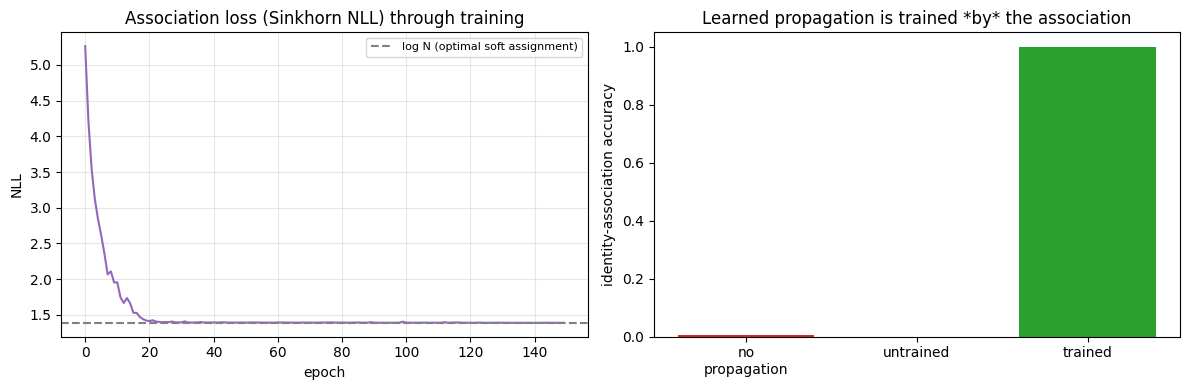

In [5]:
prop, fuse = Propagator(D), Fuser(D)
eval_seeds = list(range(5000, 5016))
acc_identity = assoc_accuracy(lambda x: x, eval_seeds)          # no propagation
acc_untrained = assoc_accuracy(prop, eval_seeds)               # random init

opt = torch.optim.Adam(list(prop.parameters()) + list(fuse.parameters()), lr=3e-3)
losses = []
for epoch in range(150):
    loss = rollout(prop, fuse, *rot_clip(epoch))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
acc_trained = assoc_accuracy(prop, eval_seeds)

print(f"association loss {losses[0]:.3f} -> {losses[-1]:.3f}  "
      f"(optimum = log N = {torch.tensor(float(N)).log():.3f})")
print(f"association accuracy   no-propagation: {acc_identity:.3f}")
print(f"                       untrained:      {acc_untrained:.3f}")
print(f"                       TRAINED:        {acc_trained:.3f}")

fig, (axl, axb) = plt.subplots(1, 2, figsize=(12, 4))
axl.plot(losses, color="tab:purple")
axl.axhline(float(torch.tensor(float(N)).log()), ls="--", color="0.5",
            label="log N (optimal soft assignment)")
axl.set_title("Association loss (Sinkhorn NLL) through training")
axl.set_xlabel("epoch"); axl.set_ylabel("NLL"); axl.legend(fontsize=8)
axl.grid(alpha=0.3)
axb.bar(["no\npropagation", "untrained", "trained"],
        [acc_identity, acc_untrained, acc_trained],
        color=["tab:red", "tab:orange", "tab:green"])
axb.set_ylim(0, 1.05); axb.set_ylabel("identity-association accuracy")
axb.set_title("Learned propagation is trained *by* the association")
plt.tight_layout(); plt.show()


In [6]:
# Deploy the trained modules in a REAL unitrack.Tracker (hard Jonker
# matching) and measure how often each track keeps its own identity.
def emb_state(process, observation):
    return {"emb": State(schema=TensorSpec(shape=(D,), dtype=torch.float32),
                         process=process, observation=observation,
                         init=FromDetectionField("emb"))}

def deploy_accuracy(states):
    tr = unitrack.Tracker(
        root=Pipe(cost=Cosine("emb"), assoc=Associate(Jonker(threshold=0.95))),
        states=states, lifecycle=NoLifecycle(), visibility=IncludeAll())
    ms = unitrack.MultiStream(tr)
    frames, _ = rot_clip(99, shuffle=False)     # column j == identity j
    correct = total = 0
    for k in range(ROT_T):
        d = Detections(index=torch.arange(N, dtype=torch.int64),
                       emb=frames[k].clone(), batch_size=[N])
        res = ms.step(stream_key=0, detections=d,
                      ctx=FrameContext.make(k, delta=1.0, stream_key=0))
        if k > 0:                               # correct pair is (row i, col i)
            p = res.match.matched_pairs
            correct += int((p[:, 0] == p[:, 1]).sum()); total += p.shape[0]
    return correct / max(total, 1)

with torch.no_grad():
    dep_learned = deploy_accuracy(emb_state(
        LearnedProcess("emb", prop),
        LearnedObservation("emb", "emb", fuse)))
    dep_plain = deploy_accuracy(emb_state(Identity("emb"), Replace("emb")))
print(f"deployed in a real Tracker (hard matching):")
print(f"  identity process + replace : {dep_plain:.3f}  (lags the rotation -> swaps)")
print(f"  learned process + learned fuse: {dep_learned:.3f}  (anticipates -> holds)")


deployed in a real Tracker (hard matching):
  identity process + replace : 0.222  (lags the rotation -> swaps)
  learned process + learned fuse: 1.000  (anticipates -> holds)


**Takeaway.** A **gallery** adds memory the single-vector filters lack
— decisive across appearance changes and re-identification gaps.
**Learned propagation** is the MOTR-style option: the propagation and
update modules are trained end-to-end *through the differentiable
association*, not by regressing to a target embedding — the only
supervision is "keep each identity matched". With that signal the
module learns to anticipate motion that a closed-form filter cannot,
and it drops into the same `State` interface (`LearnedProcess` /
`LearnedObservation`) as every other method here.
